# Motor Insurance GLM Pricing Project

This notebook contains the end-to-end implementation of a modern actuarial pricing engine for personal motor insurance. It includes synthetic data generation, exploratory data analysis (EDA), frequency/severity modeling using Generalized Linear Models (GLMs), and model validation.

## 1. Synthetic Data Generation
Generates 50,000 realistic policies with injected heterogeneity, missing values, non-linear risk relationships, and heavy-tailed large losses.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_policies = 50000

# Base features
data = {
    'Policy_ID': [f'POL{i:06d}' for i in range(n_policies)],
    'Exposure': np.clip(np.random.normal(0.8, 0.2, n_policies), 0.1, 1.0),
    'Driver_Age': np.random.randint(18, 85, n_policies),
    'Vehicle_Age': np.random.randint(0, 20, n_policies),
    'NCD': np.random.randint(0, 6, n_policies),
    'Region': np.random.choice(['Urban', 'Suburban', 'Rural'], n_policies, p=[0.5, 0.3, 0.2]),
    'Vehicle_Power': np.random.choice(['Low', 'Medium', 'High'], n_policies, p=[0.4, 0.4, 0.2])
}
df = pd.DataFrame(data)

# Inject Missing Values (Data Quality Issue)
df.loc[df.sample(frac=0.05).index, 'Vehicle_Power'] = np.nan

# True hidden rate generation (Frequency)
base_freq = 0.05
freq_multiplier = np.ones(n_policies)
freq_multiplier = np.where(df['Driver_Age'] < 25, freq_multiplier * 1.8, freq_multiplier)
freq_multiplier = np.where(df['Region'] == 'Urban', freq_multiplier * 1.3, freq_multiplier)
freq_multiplier = np.where(df['NCD'] == 5, freq_multiplier * 0.6, freq_multiplier)

true_lambda = base_freq * freq_multiplier * df['Exposure']
df['Claim_Count'] = np.random.poisson(true_lambda)

# True hidden severity generation (Severity)
base_sev = 3000
sev_multiplier = np.ones(n_policies)
sev_multiplier = np.where(df['Vehicle_Age'] < 3, sev_multiplier * 1.5, sev_multiplier)
sev_multiplier = np.where(df['Vehicle_Power'] == 'High', sev_multiplier * 1.4, sev_multiplier)

# Generate claim costs using Gamma distribution for those with claims
df['Claim_Cost'] = 0.0
has_claim = df['Claim_Count'] > 0

shape = 2.0
scale = (base_sev * sev_multiplier[has_claim]) / shape
df.loc[has_claim, 'Claim_Cost'] = np.random.gamma(shape, scale)

# Inject Outliers (Large Losses)
outlier_idx = df[has_claim].sample(frac=0.01).index
df.loc[outlier_idx, 'Claim_Cost'] *= np.random.uniform(5, 10, len(outlier_idx))

df.to_csv('motor_pricing_data.csv', index=False)
print('Synthetic Data Generated: motor_pricing_data.csv')
display(df.head())

Synthetic Data Generated: motor_pricing_data.csv


,Policy_ID,Exposure,Driver_Age,Vehicle_Age,NCD,Region,Vehicle_Power,Claim_Count,Claim_Cost
0,POL000000,0.899343,43,3,5,Rural,NaN,0,0.0
1,POL000001,0.772347,28,1,5,Urban,Low,0,0.0
2,POL000002,0.929538,37,1,0,Urban,High,0,0.0
3,POL000003,1.000000,61,0,0,Suburban,Low,0,0.0
4,POL000004,0.753169,35,4,0,Urban,Medium,0,0.0


## 2. Exploratory Data Analysis (EDA)
Analyzing one-way marginal summaries weighted by exposure.

,Exposure,Claim_Count,Claim_Cost,Frequency,Severity,Pure_Premium
Driver_Age_Band,,,,,,
"(17, 25]",4648.395059,436,1.564603e+06,0.093796,3588.539136,336.589951
"(25, 35]",5921.430906,312,1.118099e+06,0.052690,3583.650439,188.822424
"(35, 50]",8812.584838,481,1.886287e+06,0.054581,3921.594003,214.044659
"(50, 65]",8707.760847,466,1.628445e+06,0.053515,3494.517788,187.010796
"(65, 100]",11075.451993,597,2.010622e+06,0.053903,3367.875865,181.538586


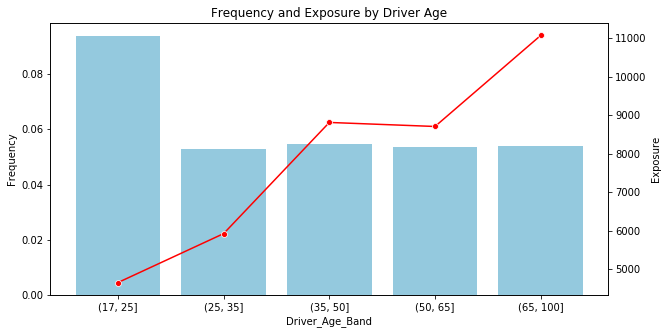

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Engineering for EDA (Banding)
df['Driver_Age_Band'] = pd.cut(df['Driver_Age'], bins=[17, 25, 35, 50, 65, 100])

# Frequency and Severity Summary by Age Band
eda_summary = df.groupby('Driver_Age_Band', observed=False).agg(
    Exposure=('Exposure', 'sum'),
    Claim_Count=('Claim_Count', 'sum'),
    Claim_Cost=('Claim_Cost', 'sum')
)
eda_summary['Frequency'] = eda_summary['Claim_Count'] / eda_summary['Exposure']
eda_summary['Severity'] = np.where(eda_summary['Claim_Count'] > 0, 
                                   eda_summary['Claim_Cost'] / eda_summary['Claim_Count'], 0)
eda_summary['Pure_Premium'] = eda_summary['Frequency'] * eda_summary['Severity']

display(eda_summary)

# Plotting Frequency vs Exposure
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(x=eda_summary.index, y=eda_summary['Frequency'], color='skyblue', ax=ax1)
ax1.set_ylabel('Frequency')
ax2 = ax1.twinx()
sns.lineplot(x=eda_summary.index.astype(str), y=eda_summary['Exposure'], color='red', marker='o', ax=ax2)
ax2.set_ylabel('Exposure')
plt.title('Frequency and Exposure by Driver Age')
plt.show()

## 3. Model Development (GLM)
Fitting a Poisson GLM (Frequency) and a Gamma GLM (Severity) using statsmodels.

In [3]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

# Data Cleaning & Prep
df['Vehicle_Power'] = df['Vehicle_Power'].fillna('Unknown')
df['Offset'] = np.log(df['Exposure'])

# Train/Test Split
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

# 1. Frequency Model (Poisson)
print('--- Fitting Frequency Model ---')
freq_formula = 'Claim_Count ~ C(Region) + C(Vehicle_Power) + Driver_Age + C(NCD) + Vehicle_Age'
freq_model = smf.glm(formula=freq_formula, 
                     data=train_df, 
                     family=sm.families.Poisson(link=sm.families.links.Log()),
                     offset=train_df['Offset']).fit()
print(freq_model.summary())

# 2. Severity Model (Gamma - Only where claims > 0)
print('\n--- Fitting Severity Model ---')
train_df_sev = train_df[train_df['Claim_Count'] > 0].copy()

# Cap large losses at 99th percentile for stability
cap = train_df_sev['Claim_Cost'].quantile(0.99)
train_df_sev['Claim_Cost_Capped'] = train_df_sev['Claim_Cost'].clip(upper=cap)
train_df_sev['Avg_Claim_Cost'] = train_df_sev['Claim_Cost_Capped'] / train_df_sev['Claim_Count']

sev_formula = 'Avg_Claim_Cost ~ C(Region) + C(Vehicle_Power) + Vehicle_Age'
sev_model = smf.glm(formula=sev_formula, 
                    data=train_df_sev, 
                    family=sm.families.Gamma(link=sm.families.links.Log()),
                    var_weights=train_df_sev['Claim_Count']).fit()
print(sev_model.summary())

# Predict on Test Set
test_df['Pred_Freq'] = freq_model.predict(test_df) / test_df['Exposure'] # Annualized frequency
test_df['Pred_Sev'] = sev_model.predict(test_df)
test_df['Pred_Pure_Premium'] = test_df['Pred_Freq'] * test_df['Pred_Sev']

--- Fitting Frequency Model ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:            Claim_Count   No. Observations:                35000
Model:                            GLM   Df Residuals:                    34987
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6465.6
Date:                Mon, 01 Jun 2026   Deviance:                       9788.8
Time:                        02:26:31   Pearson chi2:                 3.49e+04
No. Iterations:                     6   Pseudo R-squ. (CS):           0.003263
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

C:\Users\DELL\anaconda3\lib\site-packages\ipykernel_launcher.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\DELL\anaconda3\lib\site-packages\ipykernel_launcher.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\DELL\anaconda3\lib\site-packages\ipykernel_launcher.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

## 4. Model Validation
Calculating the Gini Coefficient and plotting the Lorenz Curve to prove pricing accuracy lift out-of-sample.

Model Gini Coefficient: 0.181


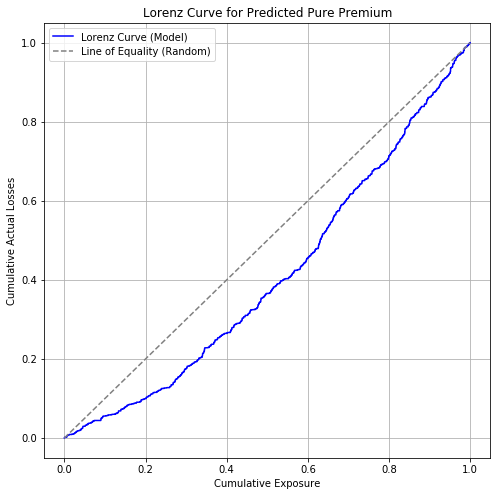

In [4]:
from sklearn.metrics import auc

def calculate_gini(df, pred_col, actual_col, exposure_col):
    sorted_df = df.sort_values(by=pred_col)
    cum_exposure = sorted_df[exposure_col].cumsum() / sorted_df[exposure_col].sum()
    cum_losses = sorted_df[actual_col].cumsum() / sorted_df[actual_col].sum()
    
    # Lorenz curve area
    lorenz_auc = auc(cum_exposure, cum_losses)
    
    # Gini = 2 * (Area between Line of Equality and Lorenz Curve)
    gini = 1 - (2 * lorenz_auc)
    return abs(gini), cum_exposure, cum_losses

gini_score, cum_exp, cum_loss = calculate_gini(test_df, 'Pred_Pure_Premium', 'Claim_Cost', 'Exposure')
print(f'Model Gini Coefficient: {gini_score:.3f}')

# Plot Lorenz Curve
plt.figure(figsize=(8, 8))
plt.plot(cum_exp, cum_loss, label='Lorenz Curve (Model)', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Line of Equality (Random)')
plt.title('Lorenz Curve for Predicted Pure Premium')
plt.xlabel('Cumulative Exposure')
plt.ylabel('Cumulative Actual Losses')
plt.legend()
plt.grid(True)
plt.show()